# Fairlearn + Representation Bias

representation bias injected + pre-processing fairness intervention from Fairlearn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from frozenlist import FrozenList

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from numpy import percentile

import fairlearn
from fairlearn.metrics import *
from fairlearn.reductions import *
import aif360

import copy, random, warnings

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.base import clone

# Data

### Dataset Class

In [2]:
class Dataset:
    def __init__(self, short_name = '', path = '', cat_cols = [], num_cols = [],
                 sens_attr = '', has_sens_attr = True,
                 sep = '', synthetic = False):
        self.short_name = short_name
        self.path = path
        self.cat_cols = cat_cols
        self.num_cols = num_cols
        self.has_sens_attr = has_sens_attr
        if has_sens_attr:
            self.sens_attr = sens_attr
        if not synthetic:
            self.df = pd.read_csv(path, sep = sep)

In [3]:
# collection of datasets is a dictionary where keys = short name, values = Dataset object

datasets = dict()

def add_dataset(dataset):
    if not isinstance(dataset, Dataset):
        raise TypeError("Please enter a valid Dataset object")
    else:
        if dataset.short_name not in datasets.keys():
            datasets[dataset.short_name] = dataset

### Popular Datasets

In [4]:
# example - adding a dataset
path_adult_income = 'Datasets/adult.csv'
cat_cols_adult = ['workclass', 'education','marital-status', 'occupation', 'relationship', 'race',
            'gender', 'native-country','income']
num_cols_adult = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
adult_income = Dataset('adult_income', path_adult_income, cat_cols_adult, num_cols_adult, sep = ",", sens_attr = 'gender')

add_dataset(adult_income)

df_adult = datasets['adult_income'].df

In [5]:
cat_cols_por = ['school', 'sex', 'address','famsize','Pstatus','Mjob','Fjob','reason',
       'guardian','schoolsup','famsup','paid', 'activities','nursery','higher', 'internet','romantic']
num_cols_por = ['age', 'Medu', 'Fedu','traveltime','studytime','failures', 'famrel',
       'freetime','goout','Dalc','Walc','health','absences','G1', 'G2', 'G3']

add_dataset(Dataset("student_por", path='Datasets/student-por.csv',
                    cat_cols=cat_cols_por, num_cols=num_cols_por, sep = ";", sens_attr = 'sex'))

### Synthetic Data

In [6]:
from synthetic_data import get_synthetic_data

In [7]:
'''
Parameters:

    n is the total number of examples in the dataset

    num_numerical_feats is number of numerical features
        each numerical feature is drawn from a
        multivariate normal distribution

    ranges = list with range of values for each numerical feature
        each element of ranges is a range [x,y)
        default is [0,1)
        NOTE: len(ranges) == num_numerical_feats

    num_types: list of values such that
        num_types[i] = 1 if integer, 0 if float for numerical feature i
        default is all integers
        NOTE: len(num_types) == num_numerical_feats

    num_cat_feats is number of categorical features

    cat_levels is an array where each element is the number
        of levels for each categorical feature
        len(cat_levels) = num_cat_feats

    r is the proportion of examples in the minority group
        (1-r) is proportion of examples in majority group

    label_noise is in [0,1]

    diff_dist is true if minority and majority have different
        underlying sampling distributions

    show_vis displays the distribution of outcomes

'''

df_synthetic = get_synthetic_data(n=10000, r = 0.25, num_numerical_feats=4, num_cat_feats=4,
                                  ranges = [(0, 100), (-25, 50), (0, 2), (-100, -50)],
                                  num_types=(1, 1, 0,0), cat_levels=[4,2,3,2], 
                                  diff_dist=True, label_noise = 0.1)

# add to dictionary of datasets
path_synthetic = 'Datasets/synthetic_data.csv'
#df_synthetic.to_csv(path_synthetic)
add_dataset(Dataset('synthetic', path_synthetic, cat_cols=[], num_cols=[], synthetic=True, sens_attr = "sens_feat"))

# EDA + Data Visualizations

In [8]:
df_synthetic['cat1'].value_counts().sort_index()

0.0    2486
1.0    2482
2.0    2538
3.0    2494
Name: cat1, dtype: int64

In [9]:
# take a peek at the first few data points
df_adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


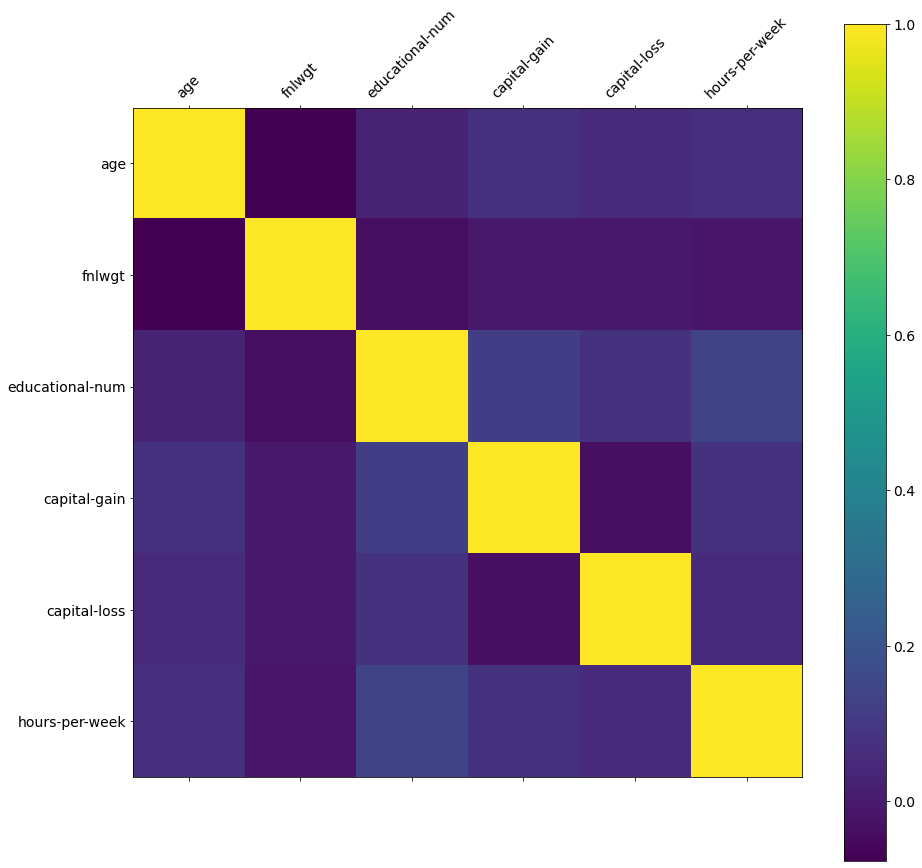

In [10]:
def corr_plot(df):
    f = plt.figure(figsize=(15, 15))
    plt.matshow(df.corr(), fignum=f.number)
    plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
    plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=14)

corr_plot(df_adult)

# Preparation

### Train/Test Split

NOTES: 
1. Whether you input your own data, choose one of our provided datasets, or generate synthetic data, we will consider this to be the UNBIASED GROUND TRUTH.
2. Then, we will split the data, with the first part being the data which we will inject bias into and the second part being the unbiased ground truth testing data.



#### One-Hot Encoding (ONLY for non-synthetic data)

In [11]:
df_adult['income']

0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: income, Length: 48842, dtype: object

In [12]:
# OHE categorical features (prompt for user's choice here?)

# get indices of categorical columns
def get_cat_cols(dataset):
    df = dataset.df
    res = []
    for col in dataset.cat_cols:
        res.append(df.columns.get_loc(col))
    return res

# df_train = pd.get_dummies(df_train, get_cat_cols(datasets['short_name']))
l = get_cat_cols(datasets['adult_income'])
df_adult_dum = pd.get_dummies(df_adult.iloc[:, :-1], l[:-1])
df_adult_dum['label'] = df_adult['income']
df_adult_dum['label'] = df_adult_dum['label'].apply(lambda x: 0 if x == "<=50K" else 1)

In [13]:
'''
    train_ratio: is the proportion of data examples in the training set
        (1-train_ratio is proportion in unbiased testing set)
'''
def train_test_split(df, train_ratio = 0.5):
    
    df_train = df.loc[range(0,int(len(df)*train_ratio)), :]
    df_test = df.loc[range(int(len(df)*train_ratio)+1, len(df)), :]
    
    return df_train, df_test

df_train, df_test = train_test_split(df_adult_dum)

### Data Preprocessing

In [14]:
df_adult['gender'].value_counts()

Male      32650
Female    16192
Name: gender, dtype: int64

In [15]:
'''

This function separates the minority and majority classes

Parameters:
    
    sens_attr: sensitive attribute
    maj_val: value of sens_attr which indicates majority class
    min_val: value of sens_attr which indicates minority class

'''
def get_maj_min(df, sens_attr, maj_val, min_val):
    assert sens_attr in list(df.columns), "Sensitive attribute must be a column in the dataframe!"
    df_majority = df[df[sens_attr] == maj_val]
    df_minority = df[df[sens_attr] == min_val]
    
    return df_majority, df_minority

df_majority, df_minority = get_maj_min(df_train, '9_Female', maj_val=1, min_val=0)

#### Formatting Data

scaling data using Standard Scaler

In [16]:
X_train = df_train.iloc[:, :-1].values
y_train = df_train.iloc[:, -1].values

In [17]:
X_true = df_test.iloc[:, :-1].values
y_true = df_test.iloc[:, -1].values

#sens_attrs_true = [df_test[datasets['adult_income'].sens_attr]]

# Bias Injection

#### Representation Bias

Under-sample an attribute conditioned on subgroups for that feature and/or subgroups for other feature(s)

Note: you will need to input $\beta$, which is the probability of deleting an example from the desired group.

In [18]:
from biases import representation

### Bias Injection

In [19]:
df_bias = representation(df_train, df_train['9_Female'] == 1, 0.5)

# format data
X_bias = df_bias.iloc[:, :-1].values
y_bias = df_bias.iloc[:, -1].values

# Model

In [20]:
# modularize and add data struct of different ml techniques

classifier = LogisticRegression(solver = 'liblinear', random_state = 42)

classifier_bias = classifier.fit(X_bias, y_bias)
y_pred_bias = classifier_bias.predict(X_bias)
y_pred_bias_on_true = classifier_bias.predict(X_true)

sens_feat_true = df_test['9_Female']
sens_feat_bias = df_bias['9_Female']

### Model Performance (TODO: modularize)

In [21]:
print("Accuracy of Biased Model on Biased Data: ", accuracy_score(y_pred_bias, y_bias))
print("Accuracy of Biased Model on Ground Truth Data: ", accuracy_score(y_pred_bias_on_true, y_true))

Accuracy of Biased Model on Biased Data:  0.7793447921257529
Accuracy of Biased Model on Ground Truth Data:  0.7966420966420966


# Correlation Remover (Fairlearn Pre-Processing Fairness Intervention)

In [22]:
from fairlearn.preprocessing import CorrelationRemover

In [23]:
remover_df = CorrelationRemover(sensitive_feature_ids=['9_Female', '9_Male'], alpha=1)
df_corr = pd.DataFrame(remover_df.fit_transform(df_bias))
df_temp = df_adult_dum.drop(['9_Female', '9_Male'], axis=1)
df_corr.columns = df_temp.columns

# correlation remover modifies outcomes, so need to re-binarize
df_corr['label'] = df_corr['label'].apply(lambda x: round(x))

In [24]:
# re-format data
X_bias_corr = df_corr.iloc[:, :-1].values
y_bias_corr = df_corr.iloc[:, -1].values

df_test_corr = df_test.drop(['9_Female', '9_Male'], axis = 1)
X_true_corr = df_test_corr.iloc[:, :-1].values
y_true_corr = df_test_corr.iloc[:, -1].values

classifier_bias = classifier.fit(X_bias_corr, y_bias_corr)
y_pred_bias = classifier_bias.predict(X_bias_corr)
y_pred_mitigated_bias_on_true = classifier_bias.predict(X_true_corr)

In [25]:
print("Accuracy of Biased Model on Biased Data: ", accuracy_score(y_pred_bias, y_bias))
print("Accuracy of Biased Model on Ground Truth Data: ", accuracy_score(y_pred_mitigated_bias_on_true, y_true_corr))

Accuracy of Biased Model on Biased Data:  0.7748396258753244
Accuracy of Biased Model on Ground Truth Data:  0.7956592956592956


# Trade-Off Visualization (Standalone)

In [26]:
# if verbose, shows "Finished iteration: ... "
# if apply_fairness, uses fairness intervention
def tradeoff_visualization(bias_amts, classifier, X_true, y_true, 
                           df_train, df_test, sensitive_feature = "cat",
                           metric_fn = accuracy_score,
                           apply_fairness = False, verbose = False):
    
    metric_on_true = []
    metric_on_biased = []
    metric_on_true_mitigated = []
    metric_on_biased_mitigated = []
    
    count = 0

    for bias in bias_amts:
        
        df_train_copy = df_train.copy()
        df_test_copy = df_test.copy()
        
        df_bias = representation(df_train, df_train[sensitive_feature] == 0, bias)

        # format data
        X_bias = df_bias.iloc[:, :-1].values
        y_bias = df_bias.iloc[:, -1].values
        
        X_bias_true = X_bias
        
        y_bias_true = df_bias.iloc[:, -1].values
        
        classifier_bias = classifier.fit(X_bias_true, y_bias_true)
        
        if apply_fairness:
            
            # pre-processing intervention
            remover_df = CorrelationRemover(sensitive_feature_ids=['9_Female', '9_Male'], alpha=1)
            df_corr = pd.DataFrame(remover_df.fit_transform(df_bias))
            df_temp = df_adult_dum.drop(['9_Female', '9_Male'], axis=1)
            df_corr.columns = df_temp.columns

            # correlation remover modifies outcomes, so need to re-binarize
            df_corr['label'] = df_corr['label'].apply(lambda x: round(x))
            
            # re-format data
            X_bias_corr = df_corr.iloc[:, :-1].values
            y_bias_corr = df_corr.iloc[:, -1].values

            df_test_corr = df_test_copy.drop(['9_Female', '9_Male'], axis = 1)
            X_true_corr = df_test_corr.iloc[:, :-1].values
            y_true_corr = df_test_corr.iloc[:, -1].values
            
            classifier_mitigated = clone(classifier)
            classifier_mitigated = classifier_mitigated.fit(X_bias_corr, y_bias_corr)
            
            # testing on biased data WITH fairness intervention
            y_pred_mitigated_bias = classifier_mitigated.predict(X_bias_corr)
            
            # testing on GT data WITH fairness intervention
            y_pred_mitigated_bias_on_true = classifier_mitigated.predict(X_true_corr)
        
        # testing on biased data withOUT fairness intervention
        y_pred_bias = classifier_bias.predict(X_bias_true)
        
        # testing on GT data withOUT fairness intervention
        y_pred_bias_on_true = classifier_bias.predict(X_true)

        # model performance
        
        if apply_fairness:
            # on biased data
            metric_bias_mitigated = metric_fn(y_pred=y_pred_mitigated_bias, y_true=y_bias_corr)
            metric_on_biased_mitigated.append(metric_bias_mitigated)
            # on GT data
            metric_bias_mitigated_on_true = metric_fn(y_pred=y_pred_mitigated_bias_on_true, y_true=y_true_corr)
            metric_on_true_mitigated.append(metric_bias_mitigated_on_true)
        
        # on biased data
        metric_bias = metric_fn(y_pred=y_pred_bias, y_true=y_bias_true)
        metric_on_biased.append(metric_bias)
        # on GT data
        metric_bias_on_true = metric_fn(y_pred=y_pred_bias_on_true, y_true=y_true)
        metric_on_true.append(metric_bias_on_true)
        
        #print(y_pred_bias, '\n Sep \n', y_pred_bias_on_true)
        
        if verbose:
            print("Finished Iteration: ", count)
            count +=1

    return bias_amts, metric_on_biased, metric_on_true, \
           metric_on_biased_mitigated, metric_on_true_mitigated

In [27]:
def accuracy_visualizations(bias_amts,
                            metric_on_biased = [], metric_on_true = [],
                            metric_on_biased_mitigated = [],
                            metric_on_true_mitigated = [], fairness = False):
    
    if fairness:
        plt.figure(figsize=(17,7))

        plt.plot(bias_amts, metric_on_true_mitigated, label = 'Ground Truth')
        plt.plot(bias_amts, metric_on_biased_mitigated, label = 'Biased Data')
        plt.xlabel("Amount of Bias (number of minority samples removed)")
        plt.ylabel("Metric Score")
        plt.title("Biased Model Metric")
        plt.legend()

        plt.show()
        
    else:
        plt.figure(figsize=(17,7))

        plt.plot(bias_amts, metric_on_true, label = 'Ground Truth')
        plt.plot(bias_amts, metric_on_biased, label = 'Biased Data')
        plt.xlabel("Amount of Bias (number of minority samples removed)")
        plt.ylabel("Metric Score")
        plt.title("Biased Model Metric")
        plt.legend()

        plt.show()

In [28]:
def total_visualizations(bias_amts, metric_on_biased, metric_on_true,
                        metric_on_biased_mitigated, metric_on_true_mitigated):
    plt.figure(figsize=(17,7))
    plt.subplot(1,2,1)
    plt.plot(bias_amts, metric_on_biased, label = 'Tested On Biased Data + No Fairness Intervention', color = "red")
    plt.plot(bias_amts, metric_on_biased_mitigated, label = 'Tested On Biased Data + Fairness Intervention', color = "green")
    plt.plot(bias_amts, metric_on_true, label = 'Tested On Ground Truth + No Fairness Intervention', color = "blue")
    plt.plot(bias_amts, metric_on_true_mitigated, label = 'Tested On Ground Truth + Fairness Intervention', color = "purple")
    plt.xlabel("Amount of Bias (number of minority samples removed)")
    plt.ylabel("Metric Score")
    plt.title("Metric of Biased Model (trained on biased data)")
    plt.legend()
    plt.show()

In [29]:
warnings.filterwarnings('ignore')

classifier = LogisticRegression(solver='liblinear', random_state=42)

bias_amts = np.divide(list(range(10,-1,-1)),10)[::-1]

bias_amts, metric_on_biased, metric_on_true, \
           metric_on_biased_mitigated, metric_on_true_mitigated = \
tradeoff_visualization(bias_amts, classifier, X_true, y_true,
                       df_train, df_test, "9_Female",
                       metric_fn=recall_score,
                       apply_fairness=True, verbose=False)

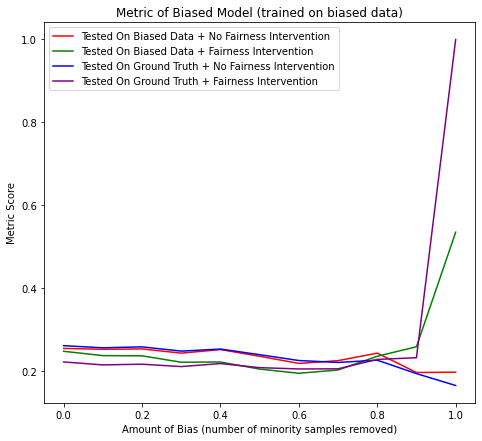

In [30]:
total_visualizations(bias_amts, metric_on_biased, metric_on_true,
                     metric_on_biased_mitigated, metric_on_true_mitigated)

# Trade-Off Visualization (Error Bars)

In [31]:
# ERROR BAR
def tradeoff_visualization_error(bias_amts, classifier, X_true, y_true, 
                           df_train, df_test, sensitive_feature = "cat",
                           metric_fn = accuracy_score,
                           apply_fairness = False, verbose = False, num_iters = 1):
    total_metric_on_true = []
    total_metric_on_biased = []
    total_metric_on_true_mitigated = []
    total_metric_on_biased_mitigated = []
    
    for i in range(num_iters):
        _, metric_bias, metric_true, metric_bias_mit, metric_true_mit = \
        tradeoff_visualization(bias_amts, classifier, X_true, y_true,
                               df_train, df_test, sensitive_feature,
                               metric_fn, apply_fairness, verbose)
                
        total_metric_on_biased.append(metric_bias)
        total_metric_on_biased_mitigated.append(metric_bias_mit)
        total_metric_on_true.append(metric_true)
        total_metric_on_true_mitigated.append(metric_true_mit)
        
        if verbose:
                print("Finished Total Iteration: ", i+1)

    mean_biased = np.mean(total_metric_on_biased, axis = 0)
    mean_biased_mitigated = np.mean(total_metric_on_biased_mitigated, axis = 0)
    mean_true = np.mean(total_metric_on_true, axis = 0)
    mean_true_mitigated = np.mean(total_metric_on_true_mitigated, axis = 0)

    y_err_biased = np.std(total_metric_on_biased, axis = 0)
    y_err_biased_mitigated = np.std(total_metric_on_biased_mitigated, axis = 0)
    y_err_true = np.std(total_metric_on_true, axis = 0)
    y_err_true_mitigated = np.std(total_metric_on_true_mitigated, axis = 0)

    return bias_amts, mean_biased, mean_true, \
           mean_biased_mitigated, mean_true_mitigated, y_err_biased, \
           y_err_true, y_err_biased_mitigated, y_err_true_mitigated

In [32]:
def total_visualizations_error(bias_amts, mean_biased, mean_true,
                        mean_biased_mitigated, mean_true_mitigated):
    plt.figure(figsize=(10,7))
    plt.errorbar(bias_amts, mean_biased, yerr= y_err_biased, label = 'Tested On Biased Data + No Fairness Intervention', color = "red")
    plt.errorbar(bias_amts, mean_biased_mitigated, yerr= y_err_biased_mitigated, label = 'Tested On Biased Data + Fairness Intervention', color = "green")
    plt.errorbar(bias_amts, mean_true, yerr= y_err_true, label = 'Tested On Ground Truth + No Fairness Intervention', color = "blue")
    plt.errorbar(bias_amts, mean_true_mitigated, yerr= y_err_true_mitigated, label = 'Tested On Ground Truth + Fairness Intervention', color = "purple")
    plt.xlabel("Beta Value")
    plt.ylabel("Metric Score")
    plt.title("Metric of Biased Model (trained on biased data)")
    plt.legend()
    plt.show()

In [33]:
classifier = LogisticRegression(solver='liblinear', random_state=42)

bias_amts = np.divide(list(range(10,-1,-1)),10)[::-1]

bias_amts, mean_biased, mean_true, \
           mean_biased_mitigated, mean_true_mitigated, y_err_biased, \
           y_err_true, y_err_biased_mitigated, y_err_true_mitigated = \
tradeoff_visualization_error(bias_amts, classifier, X_true, y_true,
                       df_train, df_test, "9_Female",
                       metric_fn=accuracy_score,
                       apply_fairness=True, verbose=False, num_iters=10)

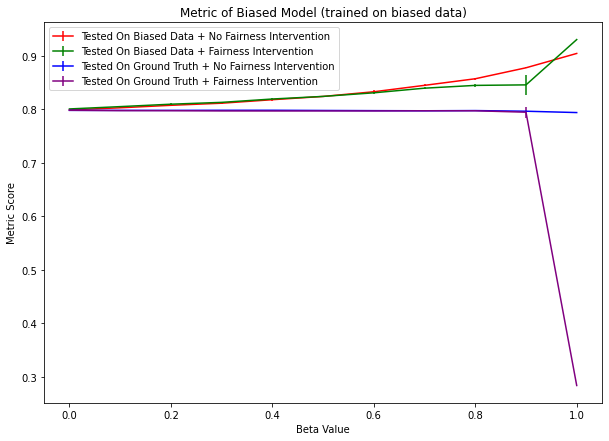

In [34]:
total_visualizations_error(bias_amts, mean_biased, mean_true,
                    mean_biased_mitigated, mean_true_mitigated)

In [35]:
bias_amts, mean_biased, mean_true, \
           mean_biased_mitigated, mean_true_mitigated, y_err_biased, \
           y_err_true, y_err_biased_mitigated, y_err_true_mitigated = \
tradeoff_visualization_error(bias_amts, classifier, X_true, y_true,
                       df_train, df_test, "9_Female",
                       metric_fn=precision_score,
                       apply_fairness=True, verbose=False, num_iters=10)

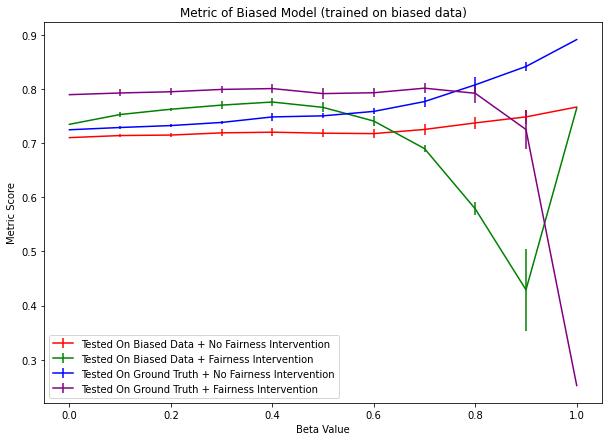

In [36]:
total_visualizations_error(bias_amts, mean_biased, mean_true,
                    mean_biased_mitigated, mean_true_mitigated)

In [37]:
bias_amts, mean_biased, mean_true, \
           mean_biased_mitigated, mean_true_mitigated, y_err_biased, \
           y_err_true, y_err_biased_mitigated, y_err_true_mitigated = \
tradeoff_visualization_error(bias_amts, classifier, X_true, y_true,
                       df_train, df_test, "9_Female",
                       metric_fn=recall_score,
                       apply_fairness=True, verbose=False, num_iters=10)

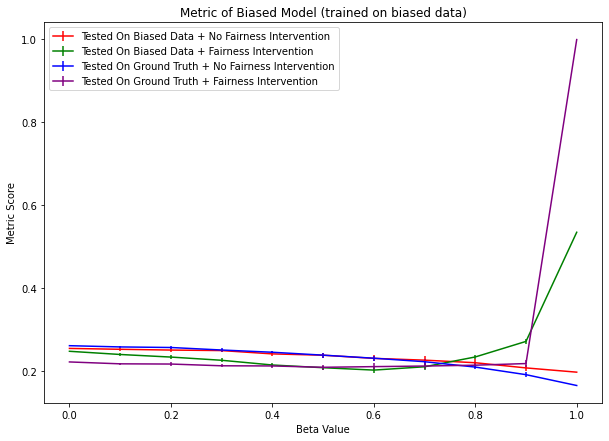

In [38]:
total_visualizations_error(bias_amts, mean_biased, mean_true,
                    mean_biased_mitigated, mean_true_mitigated)